In [13]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path as P
r = P.cwd() if (P.cwd() / "src").exists() else P.cwd().parent
sys.path[:0] = [str(r / "src"), str(r)]
from simulation_scripts.execute_simulations import *
from retrieval_methods.inline_retrieval import *

import matplotlib.pyplot as plt
from ipywidgets import IntSlider, interact

# Load Simulation Parameters

In [14]:
param_card_dict = np.load("../data/param_cards/Param_Card_PBI_Mono.npy", allow_pickle=True)

param_card_dict.item()["Initial angle (deg)"] = 0
param_card_dict.item()["Final angle (deg)"] = 360
param_card_dict.item()["Number of projections"] = 10

pd.DataFrame(param_card_dict.item().items(), columns=["Parameter", "Value"])

,Parameter,Value
0,Type of spectrum,Mono
1,Source geometry,Parallel
2,Energy (keV),20
3,Focal spot size (μm),0
4,Sim. pixel (μm),1
5,FOV (pix),"(300,300)"
6,Num. events per pixel,5000
7,Binning factor,10
8,FWHM PSF (pix),2
9,Geometry,fibre


# Calculate Reference Image

Obtaining reference and sample images for Energy = 21.0 keV


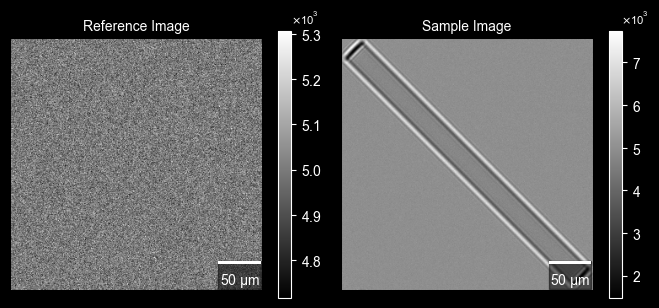

In [15]:
show_reference_Inline(param_card_dict.item())

# Save Reference (Flat-Field) and Sample Images 

In [16]:
run_Inline_sim_ct(param_card_dict.item(), save_path="../results/PBI_Mono_CT/")

Running simulation...
Obtaining reference and sample images for CT angle = 0.0 deg
Obtaining reference and sample images for Energy = 20.0 keV
Obtaining reference and sample images for CT angle = 36.0 deg
Obtaining reference and sample images for Energy = 20.0 keV
Obtaining reference and sample images for CT angle = 72.0 deg
Obtaining reference and sample images for Energy = 20.0 keV
Obtaining reference and sample images for CT angle = 108.0 deg
Obtaining reference and sample images for Energy = 20.0 keV
Obtaining reference and sample images for CT angle = 144.0 deg
Obtaining reference and sample images for Energy = 20.0 keV
Obtaining reference and sample images for CT angle = 180.0 deg
Obtaining reference and sample images for Energy = 20.0 keV
Obtaining reference and sample images for CT angle = 216.0 deg
Obtaining reference and sample images for Energy = 20.0 keV
Obtaining reference and sample images for CT angle = 252.0 deg
Obtaining reference and sample images for Energy = 20.0 ke

# Retrieve and Plot Transmission Image

In [17]:
Iref = np.load("../results/PBI_Mono_CT/I_ref_poly_ct.npy")
Isamp = np.load("../results/PBI_Mono_CT/I_samp_poly_ct.npy")
T = Isamp/Iref

In [19]:
vmin, vmax = np.nanmin(T), np.nanmax(T)

@interact(i=IntSlider(min=0, max=T.shape[0] - 1, step=1, value=0, description="Projection"))
def show_T(i):
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(T[i], cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(f"Transmission — Projection {i + 1} / {T.shape[0]}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.show()


interactive(children=(IntSlider(value=0, description='Projection', max=9), Output()), _dom_classes=('widget-in…